<a href="https://colab.research.google.com/github/anooshk2606/Nutrition-Health-Survey--Age-Prediction-Summer-Analytics-2026-IIT-Guwahati--Hackathon-/blob/main/Copy_of_week4_hackathon.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Evaluation
from sklearn.metrics import f1_score, classification_report

In [ ]:
train = pd.read_csv("Train_dataset.csv")
test = pd.read_csv("Test_dataset.csv")
sample = pd.read_csv("Sample_submission.csv")

In [ ]:
train.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.0,2.0,2.0,35.7,110.0,2.0,150.0,14.91,Adult
1,73568.0,2.0,2.0,20.3,89.0,2.0,80.0,3.85,Adult
2,73576.0,1.0,2.0,23.2,89.0,2.0,68.0,6.14,Adult
3,73577.0,1.0,2.0,28.9,104.0,NaN,84.0,16.15,Adult
4,73580.0,2.0,1.0,35.9,103.0,2.0,81.0,10.92,Adult


In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1966 entries, 0 to 1965
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   SEQN       1954 non-null   float64
 1   RIAGENDR   1948 non-null   float64
 2   PAQ605     1953 non-null   float64
 3   BMXBMI     1948 non-null   float64
 4   LBXGLU     1953 non-null   float64
 5   DIQ010     1948 non-null   float64
 6   LBXGLT     1955 non-null   float64
 7   LBXIN      1957 non-null   float64
 8   age_group  1952 non-null   object 
dtypes: float64(8), object(1)
memory usage: 138.4+ KB


In [ ]:
train.describe()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN
count,1954.000000,1948.000000,1953.000000,1948.000000,1953.000000,1948.000000,1955.000000,1957.000000
mean,78683.621801,1.510267,1.825397,27.965400,99.491039,2.015914,115.150384,11.862892
std,2924.115709,0.500023,0.399449,7.327616,16.774665,0.187579,46.271615,9.756713
min,73564.000000,1.000000,1.000000,14.500000,63.000000,1.000000,40.000000,0.140000
25%,76194.000000,1.000000,2.000000,22.800000,91.000000,2.000000,87.000000,5.800000
50%,78717.000000,2.000000,2.000000,26.800000,97.000000,2.000000,105.000000,9.030000
75%,81217.000000,2.000000,2.000000,31.300000,104.000000,2.000000,131.000000,14.480000
max,83727.000000,2.000000,7.000000,70.100000,405.000000,3.000000,604.000000,102.290000


In [ ]:
train.shape

(1966, 9)

In [ ]:
test.shape

(312, 8)

In [ ]:
train.isnull().sum()

,0
SEQN,12
RIAGENDR,18
PAQ605,13
BMXBMI,18
LBXGLU,13
DIQ010,18
LBXGLT,11
LBXIN,9
age_group,14


In [ ]:
test.isnull().sum()

,0
SEQN,2
RIAGENDR,2
PAQ605,1
BMXBMI,1
LBXGLU,1
DIQ010,1
LBXGLT,2
LBXIN,1


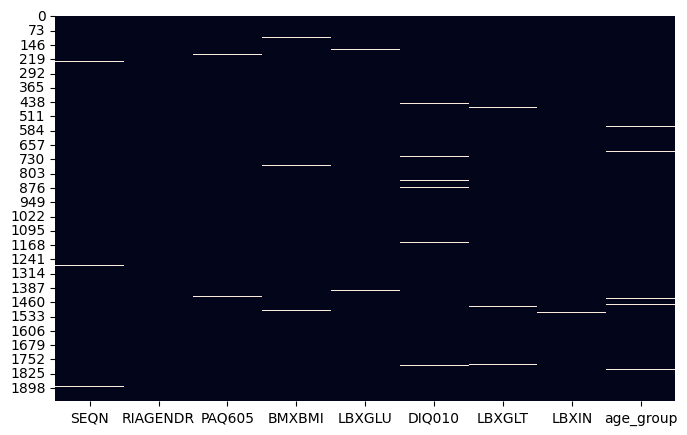

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(train.isnull(),cbar=False)
plt.show()

In [ ]:
train["age_group"].value_counts()

,count
age_group,
Adult,1638
Senior,314


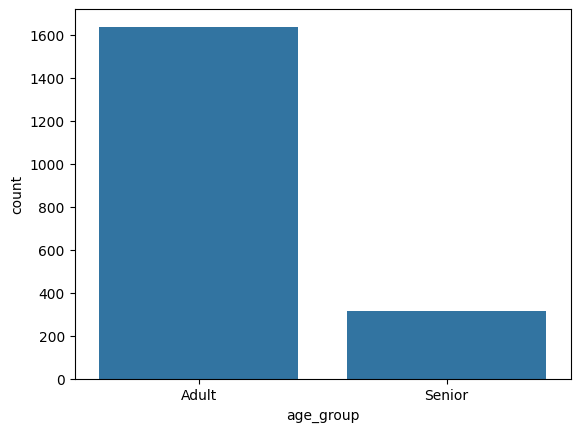

In [ ]:
sns.countplot(x="age_group",data=train)
plt.show()

In [ ]:
num_cols =["BMXBMI","LBXGLU","LBXGLT","LBXIN"]

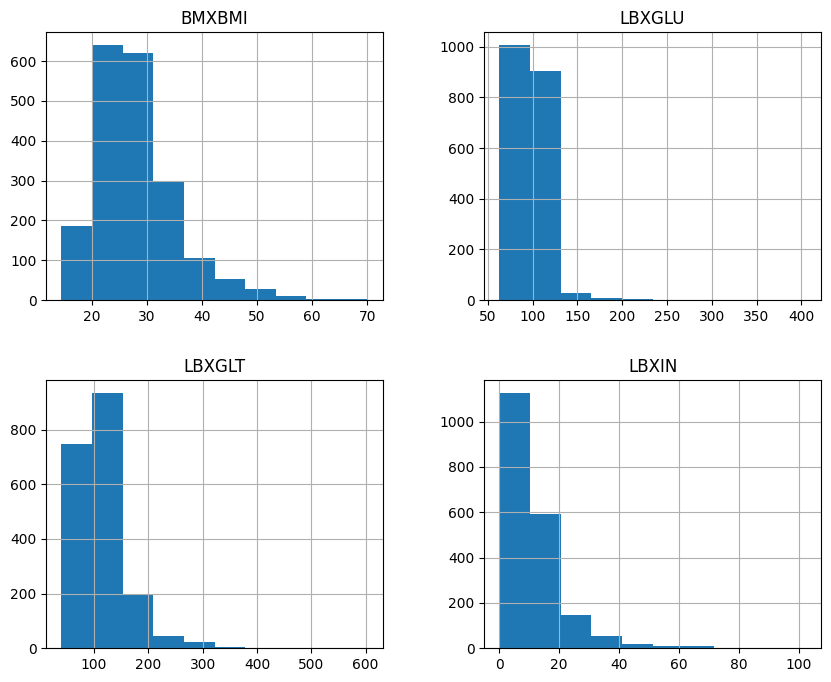

In [ ]:
train[num_cols].hist(figsize=(10,8))
plt.show()

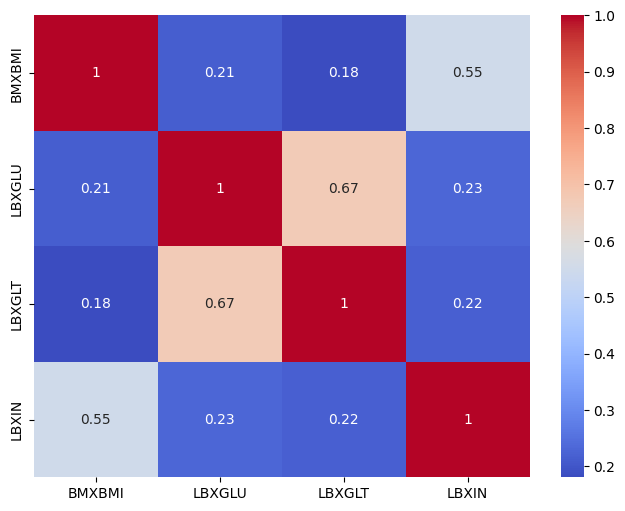

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(train[num_cols].corr(),annot =True,cmap="coolwarm")
plt.show()

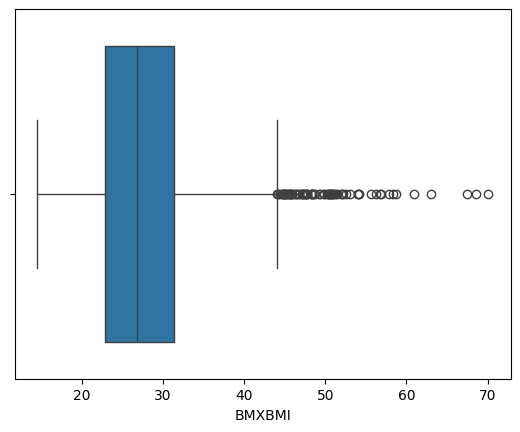

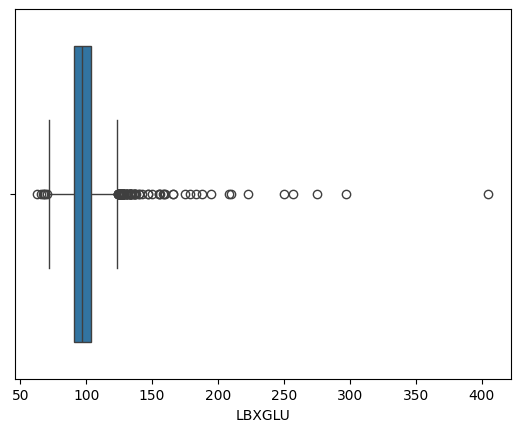

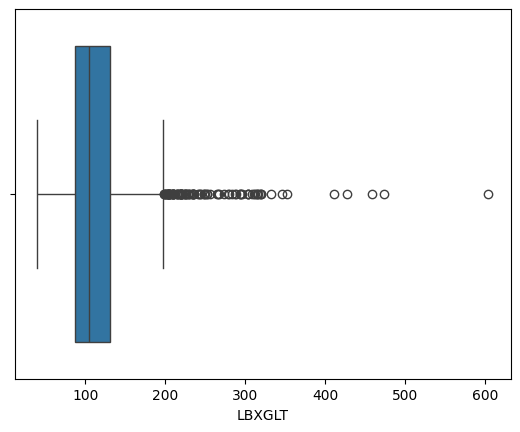

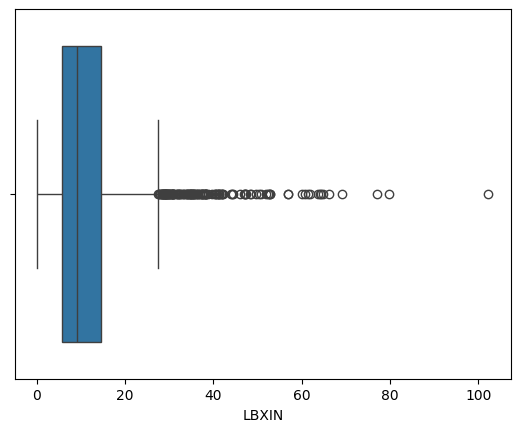

In [ ]:
for col in num_cols:
  sns.boxplot(x=train[col])
  plt.show()

In [ ]:
X= train.drop(["age_group"],axis=1)
y= train["age_group"]
X_test = test.copy()

In [ ]:
X=X.drop("SEQN",axis =1)
X_test =X_test.drop("SEQN",axis=1)

In [ ]:
imputer = SimpleImputer(strategy="median")

X = pd.DataFrame(imputer.fit_transform(X),columns=X.columns)

X_test = pd.DataFrame(imputer.transform(X_test),columns=X_test.columns)

In [ ]:
X["HighBMI"] = (X["BMXBMI"]>=30).astype(int)

X_test["HighBMI"] = (X_test["BMXBMI"]>=30).astype(int)

In [ ]:
X["HighGlucose"] = (X["LBXGLU"]>=126).astype(int)

X_test["HighGlucose"] = (X_test["LBXGLU"]>=126).astype(int)

In [ ]:
X["Glucose_Insulin"] = X["LBXGLU"]*X["LBXIN"]

X_test["Glucose_Insulin"] = X_test["LBXGLU"]*X_test["LBXIN"]

In [ ]:
X["BMI_GLU"] = X["BMXBMI"]*X["LBXGLU"]

X_test["BMI_GLU"] = X_test["BMXBMI"]*X_test["LBXGLU"]

In [ ]:
X["Activity_Diabetes"] = X["PAQ605"]*X["DIQ010"]

X_test["Activity_Diabetes"] = X_test["PAQ605"]*X_test["DIQ010"]

In [ ]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_test_scaled = scaler.transform(X_test)

In [ ]:

lr = LogisticRegression(max_iter=1000)

In [ ]:
print(y.isnull().sum())

14


In [ ]:
print(y.value_counts(dropna=False))

age_group
Adult     1638
Senior     314
NaN         14
Name: count, dtype: int64


In [ ]:
data = X.copy()
data["age_group"] = y

data = data.dropna(subset=["age_group"])

X = data.drop("age_group", axis=1)
y = data["age_group"]

In [ ]:
X_train,X_valid,y_train,y_valid=train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
print(y_train.unique())

['Adult' 'Senior']


In [ ]:
lr=LogisticRegression(max_iter=500)

lr.fit(X_train,y_train)

pred=lr.predict(X_valid)

print(f1_score(y_valid, pred, pos_label="Senior"))

0.13157894736842105


In [ ]:
rf=RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

pred=rf.predict(X_valid)
print(f1_score(y_valid, pred, pos_label="Senior"))


0.1927710843373494


In [ ]:
et=ExtraTreesClassifier(
    n_estimators=500,
    random_state=42
)

et.fit(X_train,y_train)

pred=et.predict(X_valid)


In [ ]:

print(f1_score(y_valid, pred, pos_label="Senior"))

0.20689655172413793


In [ ]:
gb=GradientBoostingClassifier()

gb.fit(X_train,y_train)

pred=gb.predict(X_valid)

print(f1_score(y_valid,pred, pos_label="Senior"))

0.1686746987951807


In [ ]:
cv=StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
scores=cross_val_score(
    et,
    X,
    y,
    scoring="f1_weighted",
    cv=cv
)

scores.mean()

np.float64(0.7988364110050844)

In [ ]:
et.fit(X,y)

ExtraTreesClassifier(n_estimators=500, random_state=42)

In [ ]:
predictions=et.predict(X_test)

In [ ]:
submission=pd.DataFrame({
    "age_group":predictions
})

In [ ]:
submission.head()

,age_group
0,Adult
1,Adult
2,Adult
3,Adult
4,Adult


In [ ]:
submission.to_csv("submission.csv",index=False)

In [ ]:
submission = pd.DataFrame({
    "age_group": pred
})

submission["age_group"] = submission["age_group"].map({
    "Adult": 0,
    "Senior": 1
})

submission.to_csv("submission.csv", index=False)